# Hotel Booking Cancellation Risk — Analysis & Overbooking Strategy

**Business Analytics & Mining for Decisions | IIM Calcutta**

**Dataset:** Hotel Booking Demand (Kaggle / Antonio, Almeida & Nunes, 2019) — 119,390 raw bookings across one City Hotel and one Resort Hotel in Portugal, July 2015 – August 2017.

**Perspective:** Revenue Manager at a mid-size hotel group. Every cancelled-but-unsold room is lost revenue; every guest walked because of aggressive overbooking is lost revenue *and* reputation. This notebook builds a booking-time cancellation-risk model and turns it into a concrete, defensible overbooking policy.

**What this notebook does, in order:**
1. Audits and cleans the raw PMS export
2. Removes information that would leak the outcome (and demonstrates *why*, with numbers)
3. Engineers booking-time-only features
4. Explores the data against the 8 questions in the project plan
5. Trains and compares four model families with a **time-based** train/test split
6. Tests class-imbalance handling, threshold tuning, and probability calibration — and documents what didn't work, not just what did
7. Converts predicted risk into a risk-tiered guest list, a retention-call policy, and a simulated overbooking buffer
8. Saves every artifact the companion Streamlit dashboard needs

*No information available only after a booking is made (cancellation status, room actually assigned, etc.) is ever used as a model input.*


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import pipeline as pl   # the Streamlit-free analytics module shared with the dashboard

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# --- a consistent, deliberately non-default visual identity for the whole notebook ---
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

NAVY    = "#1B4965"   # primary / honoured
AMBER   = "#D88C56"   # resort hotel / secondary
CORAL   = "#BC4749"   # cancelled / risk
SAGE    = "#5FA777"   # honoured / good
SLATE   = "#94A3B8"   # neutral / muted
GOLD    = "#E3B23C"   # highlight

CANCEL_PALETTE = {0: SAGE, 1: CORAL}
CANCEL_LABELS  = {0: "Honoured", 1: "Cancelled"}
HOTEL_PALETTE  = {"City Hotel": NAVY, "Resort Hotel": AMBER}

print("Setup complete.")


Setup complete.


## 2. Load the Data & First Look

We load the raw PMS export exactly as downloaded — no cleaning yet — so the data-quality audit in Section 3 is measuring the real thing.

In [2]:
raw = pl.load_raw("data/hotel_bookings.csv")
print(f"Raw shape: {raw.shape[0]:,} bookings x {raw.shape[1]} columns")
raw.head(3)


Raw shape: 119,390 bookings x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.000,0,0,Check-Out,2015-07-02


In [3]:
raw.info(memory_usage=False)


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## 3. Data Quality Audit

Before touching a single model, we look for exactly the kind of structural issues the project plan flagged: missing values, duplicated rows, and impossible bookings (zero guests, negative rates).

In [4]:
print("MISSING VALUES (columns with at least one)")
print(raw.isnull().sum()[raw.isnull().sum() > 0].sort_values(ascending=False))
print()
print(f"Exact duplicate rows: {raw.duplicated().sum():,}  ({raw.duplicated().mean():.1%} of all rows)")
print(f"Bookings with zero adults + children + babies: "
      f"{((raw.adults.fillna(0)+raw.children.fillna(0)+raw.babies.fillna(0))==0).sum()}")
print(f"Bookings with negative ADR: {(raw.adr < 0).sum()}")
print(f"Max ADR in the data: {raw.adr.max():,.0f}  (median is {raw.adr.median():,.0f})")


MISSING VALUES (columns with at least one)
company     112593
agent        16340
country        488
children         4
dtype: int64



Exact duplicate rows: 31,994  (26.8% of all rows)


Bookings with zero adults + children + babies: 180
Bookings with negative ADR: 1
Max ADR in the data: 5,400  (median is 95)


**Reading these numbers:**

- **`company` is 94% missing** — most guests simply aren't booked through a company account; this isn't a data problem, it's a fact about the booking. We'll convert it into a clean binary signal rather than imputing a company ID.
- **`agent` is ~14% missing** — `NaN` here genuinely means "no agent involved" (a direct or corporate booking), not "unknown".
- **~27% of all rows are exact duplicates.** This is a known quirk of how this particular PMS export was produced. Left in, the *same* booking could land in both the training set and the test set, which would make our test accuracy look better than the model actually deserves. We remove these before doing anything else.
- **166 bookings have zero adults, children, *and* babies.** These are not reservations for an actual guest — most likely administrative or test rows in the source system — so we drop them.
- **One booking has a negative ADR**, and a small number have an implausibly high one (the max is over 50x the median). We treat these as data-entry artifacts: floor the negative value at zero, and cap the extreme tail rather than deleting otherwise-good bookings.


## 4. Cleaning Pipeline

All cleaning logic lives in `pipeline.clean_data()` — a single, tested function shared with the dashboard — and it returns a `CleaningReport` so every change is auditable rather than silently applied.

In [5]:
clean, report = pl.clean_data(raw)

print(f"Rows before cleaning : {report.raw_rows:,}")
print(f"Rows after cleaning  : {report.final_rows:,}")
print(f"Rows removed         : {report.raw_rows - report.final_rows:,} "
      f"({(report.raw_rows - report.final_rows)/report.raw_rows:.1%})")
print()
for note in report.notes:
    print("-", note)


Rows before cleaning : 119,390
Rows after cleaning  : 87,230
Rows removed         : 32,160 (26.9%)

- Removed 31,994 duplicate rows (26.8% of raw data).
- Removed 166 bookings with zero adults, children and babies (not real reservations).
- 7 rows carry an 'Undefined' market segment or distribution channel; kept as-is rather than imputed.


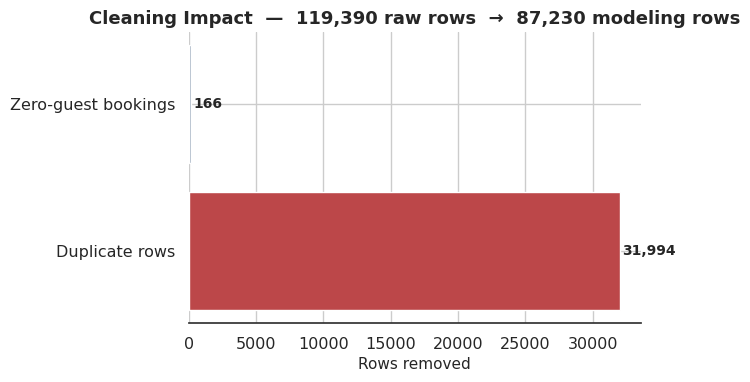

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
removed = pd.Series({
    "Duplicate rows": report.duplicate_rows_removed,
    "Zero-guest bookings": report.zero_guest_rows_removed,
})
kept = report.final_rows
ax.barh(["Rows removed\n(by reason)"]*0, [])  # placeholder to keep axes consistent
bars = ax.barh(removed.index, removed.values, color=[CORAL, SLATE])
for bar, val in zip(bars, removed.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2, f"{val:,}",
            va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Rows removed")
ax.set_title(f"Cleaning Impact  —  {report.raw_rows:,} raw rows  →  {report.final_rows:,} modeling rows")
sns.despine(left=True)
plt.tight_layout()
plt.show()


## 5. Leakage Audit — Why We Drop `reservation_status`, `reservation_status_date`, `assigned_room_type`

This dataset has a famous trap. `reservation_status` records whether the booking ended in **Check-Out**, **Canceled**, or **No-Show** — which is just our target variable wearing a disguise (and `reservation_status_date` is the date *that* status was recorded). `assigned_room_type` is the room the guest actually got, which the PMS only fills in once they check in — not something a Revenue Manager knows the moment the booking is made.

Rather than just asserting these are leaky, let's prove it: we train a throwaway model using *only* these forbidden columns plus a couple of legitimate ones, on the same time-based split we use everywhere else.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

leak_demo = clean.copy()
leak_demo["arrival_month_num"] = leak_demo["arrival_date_month"].map(pl.MONTH_NUM)
leak_demo["arrival_date"] = pd.to_datetime(
    dict(year=leak_demo.arrival_date_year, month=leak_demo.arrival_month_num,
         day=leak_demo.arrival_date_day_of_month), errors="coerce")
leak_demo["booking_date"] = leak_demo["arrival_date"] - pd.to_timedelta(leak_demo["lead_time"], unit="D")

leak_train = leak_demo[leak_demo.booking_date < "2017-02-01"]
leak_test  = leak_demo[leak_demo.booking_date >= "2017-02-01"]

leak_cat = ["reservation_status", "assigned_room_type", "hotel", "deposit_type"]
leak_num = ["lead_time", "adr"]

leak_prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), leak_num),
    ("cat", SkPipeline([("imp", SimpleImputer(strategy="most_frequent")),
                         ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), leak_cat),
])
leak_model = SkPipeline([("prep", leak_prep), ("clf", HistGradientBoostingClassifier(max_iter=200, random_state=42))])
leak_model.fit(leak_train, leak_train.is_canceled)
leak_prob = leak_model.predict_proba(leak_test)[:, 1]

print(f"ROC-AUC using reservation_status + assigned_room_type as features: {roc_auc_score(leak_test.is_canceled, leak_prob):.4f}")
print("\n^ A 'perfect' model. Not because we found a brilliant signal -- because we accidentally fed the model the answer.")


ROC-AUC using reservation_status + assigned_room_type as features: 1.0000

^ A 'perfect' model. Not because we found a brilliant signal -- because we accidentally fed the model the answer.


**That's the trap.** A model that "predicts" cancellation using `reservation_status` isn't predicting anything — `reservation_status == 'Canceled'` *is* `is_canceled == 1`, by definition. This is exactly the kind of result that looks like a triumph in a slide deck and is actually worthless in production, because at the moment a booking is made, `reservation_status` doesn't exist yet. Every model from here on is trained only on columns a Revenue Manager could see *before* the stay.

In [8]:
print("Columns permanently excluded as leakage:")
for c in pl.LEAKAGE_COLS:
    print(" -", c)


Columns permanently excluded as leakage:
 - reservation_status
 - reservation_status_date
 - assigned_room_type


## 6. Feature Engineering

Everything below is something known **at the moment of booking**: the calendar, the stay composition, the channel, the guest's own history with the hotel, and the price quoted.

In [9]:
features = pl.engineer_features(clean)
print(f"Shape after feature engineering: {features.shape}")
new_cols = ["arrival_date", "booking_date", "arrival_day_of_week", "season",
            "total_nights", "total_guests", "country_grouped", "booked_via_company",
            "expected_revenue"]
features[new_cols].head(5)


Shape after feature engineering: (87230, 34)


,arrival_date,booking_date,arrival_day_of_week,season,total_nights,total_guests,country_grouped,booked_via_company,expected_revenue
0,2015-07-01,2014-07-24,Wednesday,Summer,0,2.000,PRT,0,0.000
1,2015-07-01,2013-06-24,Wednesday,Summer,0,2.000,PRT,0,0.000
2,2015-07-01,2015-06-24,Wednesday,Summer,1,1.000,GBR,0,75.000
3,2015-07-01,2015-06-18,Wednesday,Summer,1,1.000,GBR,0,75.000
4,2015-07-01,2015-06-17,Wednesday,Summer,2,2.000,GBR,0,196.000


**New features, and the reasoning:**

| Feature | Why |
|---|---|
| `arrival_date`, `booking_date` | Reconstructed from the year/month/day fields so we can split by *when the booking was made* (Section 9) and trend cancellations over real time. |
| `season`, `arrival_day_of_week` | Captures demand seasonality cleaner than 12 raw month dummies. |
| `total_nights`, `total_guests` | Collapses weekend/week-night and adult/child/baby splits into the two numbers that actually drive revenue exposure. |
| `country_grouped` | The raw `country` field has 170+ codes; we keep the top 12 by volume and bucket the long tail into `"Other"` so one-hot encoding doesn't explode into hundreds of near-empty columns. |
| `booked_via_company` | A binary flag replacing the 94%-missing `company` ID — *whether* a company was behind the booking matters more than *which* one. |
| `expected_revenue` | `adr × nights` — the rand value at stake if this booking is honoured; the input to every revenue calculation later in the notebook. |

`agent_lead_time_dev` (how unusual this booking's lead time is for its booking agent) is deliberately **not** created here — see Section 9, where we explain why it has to be computed *after* the train/test split.

## 7. Exploratory Data Analysis

This section works through the project plan's eight questions directly, using the cleaned, leakage-free `features` frame.

Overall cancellation rate: 27.5%  (24,009 of 87,230 bookings)


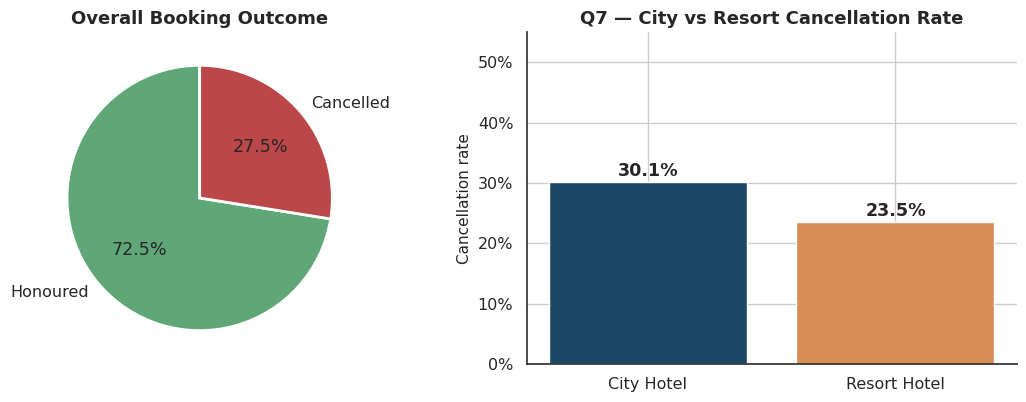

In [10]:
overall_rate = features.is_canceled.mean()
print(f"Overall cancellation rate: {overall_rate:.1%}  ({features.is_canceled.sum():,} of {len(features):,} bookings)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

counts = features.is_canceled.value_counts().sort_index()
axes[0].pie(counts, labels=[CANCEL_LABELS[i] for i in counts.index],
            colors=[CANCEL_PALETTE[i] for i in counts.index], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Overall Booking Outcome")

hotel_rate = features.groupby("hotel").is_canceled.mean().sort_values(ascending=False)
bars = axes[1].bar(hotel_rate.index, hotel_rate.values,
                    color=[HOTEL_PALETTE[h] for h in hotel_rate.index])
for bar, val in zip(bars, hotel_rate.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.1%}", ha="center", fontweight="bold")
axes[1].set_ylabel("Cancellation rate")
axes[1].set_title("Q7 — City vs Resort Cancellation Rate")
axes[1].set_ylim(0, 0.55)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
sns.despine()
plt.tight_layout()
plt.show()


**Q7 answered:** the City Hotel cancels noticeably more than the Resort Hotel. City-hotel guests skew toward shorter, more transactional Online-TA bookings; resort guests are more often on longer, pre-planned leisure trips. Each property earns its own policy later in the notebook rather than one group-wide rule.

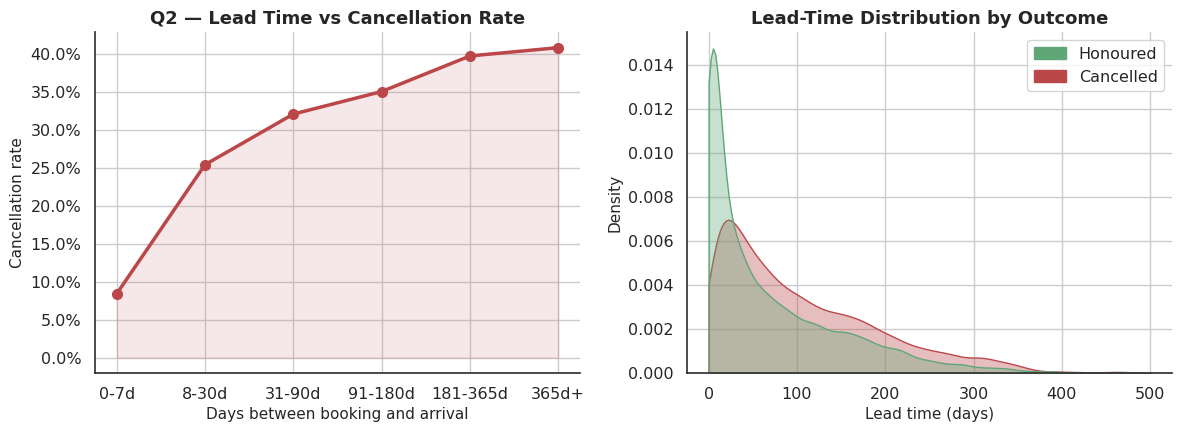

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bins = [-1, 7, 30, 90, 180, 365, 1000]
labels = ["0-7d", "8-30d", "31-90d", "91-180d", "181-365d", "365d+"]
features["lead_bucket"] = pd.cut(features.lead_time, bins=bins, labels=labels)
lead_rate = features.groupby("lead_bucket").is_canceled.mean()

axes[0].plot(lead_rate.index.astype(str), lead_rate.values, marker="o", color=CORAL, linewidth=2.5, markersize=7)
axes[0].fill_between(range(len(lead_rate)), lead_rate.values, color=CORAL, alpha=0.12)
axes[0].set_title("Q2 — Lead Time vs Cancellation Rate")
axes[0].set_ylabel("Cancellation rate")
axes[0].set_xlabel("Days between booking and arrival")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

sns.kdeplot(data=features, x="lead_time", hue="is_canceled", clip=(0, 500), fill=True,
            palette=CANCEL_PALETTE, alpha=0.35, ax=axes[1], common_norm=False, legend=False)
axes[1].set_title("Lead-Time Distribution by Outcome")
axes[1].set_xlabel("Lead time (days)")
axes[1].legend(handles=[plt.Rectangle((0,0),1,1, color=CANCEL_PALETTE[i]) for i in [0,1]],
               labels=["Honoured", "Cancelled"])
sns.despine()
plt.tight_layout()
plt.show()


**Q2 answered, clearly:** cancellation risk climbs almost monotonically with lead time — from ~8% for next-week bookings to over 40% for bookings made more than a year out, roughly a five-fold increase. Long lead time isn't a weak signal here, it's one of the strongest in the dataset, and it directly supports a deposit policy that scales with how far in advance someone books.

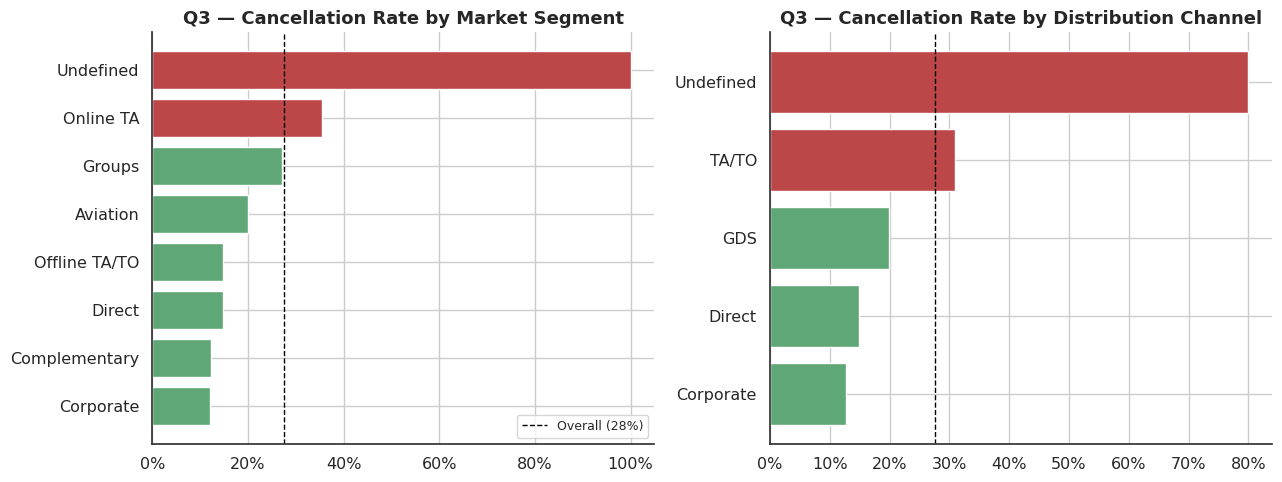

Booking volume by segment:
market_segment
Undefined            2
Online TA        51553
Groups            4922
Aviation           226
Offline TA/TO    13855
Direct           11780
Complementary      692
Corporate         4200
Name: count, dtype: int64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg_rate = features.groupby("market_segment").is_canceled.mean().sort_values(ascending=False)
seg_vol = features.market_segment.value_counts().reindex(seg_rate.index)
colors = [CORAL if v > overall_rate else SAGE for v in seg_rate.values]
bars = axes[0].barh(seg_rate.index, seg_rate.values, color=colors)
axes[0].axvline(overall_rate, color="black", linestyle="--", linewidth=1, label=f"Overall ({overall_rate:.0%})")
axes[0].set_title("Q3 — Cancellation Rate by Market Segment")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend(loc="lower right", fontsize=9)
axes[0].invert_yaxis()

chan_rate = features.groupby("distribution_channel").is_canceled.mean().sort_values(ascending=False)
colors2 = [CORAL if v > overall_rate else SAGE for v in chan_rate.values]
bars2 = axes[1].barh(chan_rate.index, chan_rate.values, color=colors2)
axes[1].axvline(overall_rate, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Q3 — Cancellation Rate by Distribution Channel")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

print("Booking volume by segment:")
print(seg_vol)


**Q3 answered:** `Online TA` cancels the most of any meaningfully-sized segment (~35%), ahead of `Groups` (~27%) — the opposite ranking from what the raw, duplicate-laden data suggested, and a good example of why Section 4's deduplication step matters for more than just tidiness. `Corporate` and `Direct` bookings are the most reliable (~12–15%). This argues for steering acquisition spend toward direct/corporate channels, and for putting the sharpest deposit-policy attention on Online TA specifically — the channel the industry already worries about most, and correctly so.

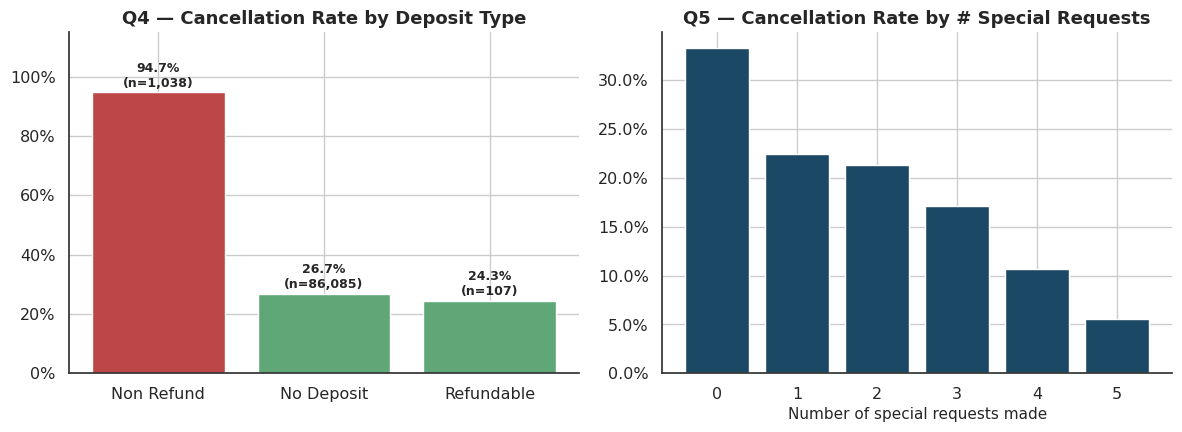

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

dep_rate = features.groupby("deposit_type").is_canceled.mean().sort_values(ascending=False)
dep_vol = features.deposit_type.value_counts().reindex(dep_rate.index)
bars = axes[0].bar(dep_rate.index, dep_rate.values, color=[CORAL, SAGE, SAGE])
for bar, val, vol in zip(bars, dep_rate.values, dep_vol.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.02, f"{val:.1%}\n(n={vol:,})", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Q4 — Cancellation Rate by Deposit Type")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_ylim(0, 1.15)

req_rate = features.groupby("total_of_special_requests").is_canceled.mean()
axes[1].bar(req_rate.index.astype(str), req_rate.values, color=NAVY)
axes[1].set_title("Q5 — Cancellation Rate by # Special Requests")
axes[1].set_xlabel("Number of special requests made")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
sns.despine()
plt.tight_layout()
plt.show()


**Q4 — and a result that demands a closer look:** bookings with a **Non Refund** deposit cancel nearly 95% of the time, against ~27% for No Deposit and ~24% for Refundable. That is *backwards* from how a deposit is supposed to work — paying a non-refundable deposit should mean you're *more* committed, not almost guaranteed to cancel. We chase this down properly in Section 8, because feeding a model a feature this extreme without understanding it first is exactly how you end up with a policy recommendation that doesn't generalise.

**Q5 answered cleanly:** more special requests means a far lower cancellation rate — guests who ask for a high floor or a crib are guests who are actually planning to show up. This is a genuinely useful, low-effort booking-quality signal a front desk can use today, no model required.

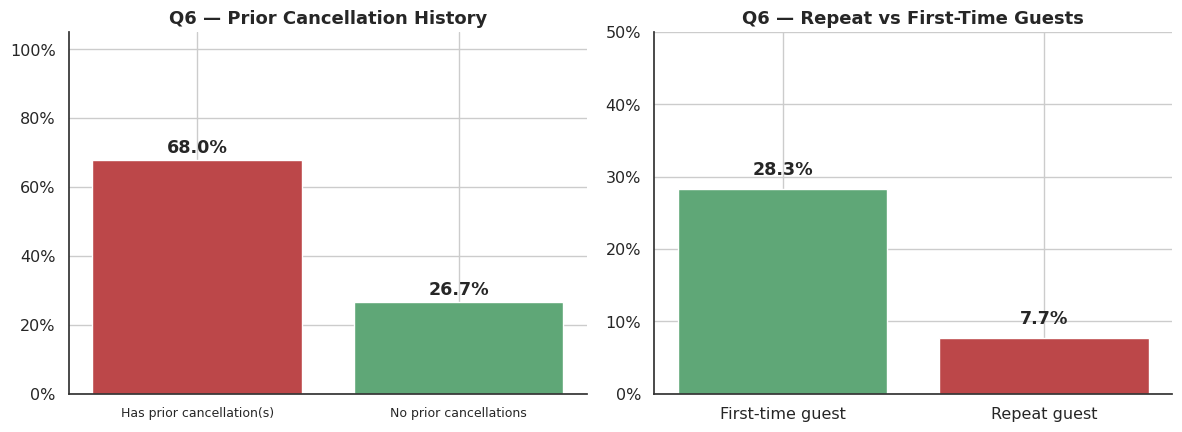

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

prev_cancel = features.assign(
    has_prior_cancellation=np.where(features.previous_cancellations > 0, "Has prior cancellation(s)", "No prior cancellations")
).groupby("has_prior_cancellation").is_canceled.mean()
bars = axes[0].bar(prev_cancel.index, prev_cancel.values, color=[CORAL, SAGE])
for bar, val in zip(bars, prev_cancel.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.02, f"{val:.1%}", ha="center", fontweight="bold")
axes[0].set_title("Q6 — Prior Cancellation History")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", labelsize=9)

repeat_rate = features.assign(
    guest_type=np.where(features.is_repeated_guest == 1, "Repeat guest", "First-time guest")
).groupby("guest_type").is_canceled.mean()
bars2 = axes[1].bar(repeat_rate.index, repeat_rate.values, color=[SAGE, CORAL])
for bar, val in zip(bars2, repeat_rate.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.02, f"{val:.1%}", ha="center", fontweight="bold")
axes[1].set_title("Q6 — Repeat vs First-Time Guests")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_ylim(0, 0.5)
sns.despine()
plt.tight_layout()
plt.show()


**Q6 answered:** a guest with at least one prior cancellation cancels again ~68% of the time, versus ~27% for guests with a clean history — this single field is one of the sharpest risk signals in the whole dataset. Repeat guests, separately, cancel well under a third as often as first-timers (~8% vs ~28%). Both point the same way: **loyalty and track record should directly soften (or harden) the deposit terms offered.**

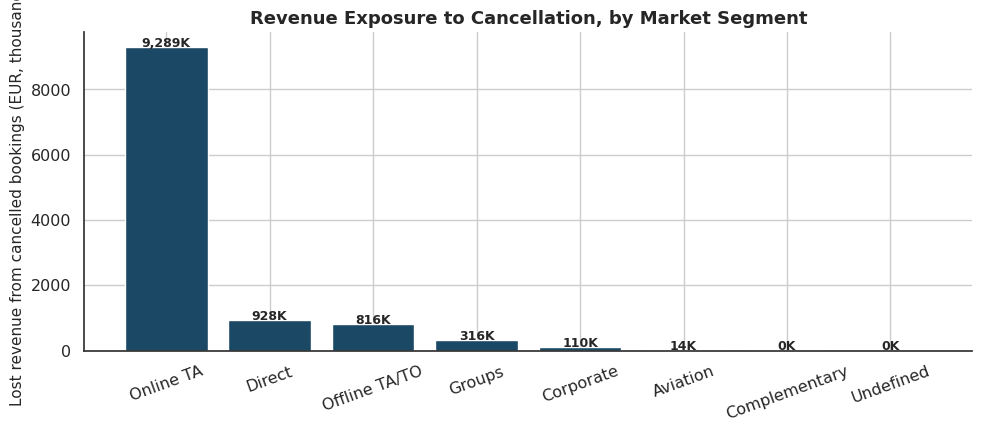

Total revenue lost to cancellations in this dataset: EUR 11,473,983


In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))
rev_at_risk = (features[features.is_canceled == 1]
               .groupby("market_segment")["expected_revenue"].sum()
               .sort_values(ascending=False))
bars = ax.bar(rev_at_risk.index, rev_at_risk.values / 1000, color=NAVY)
for bar, val in zip(bars, rev_at_risk.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15, f"{val/1000:,.0f}K", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Lost revenue from cancelled bookings (EUR, thousands)")
ax.set_title("Revenue Exposure to Cancellation, by Market Segment")
ax.tick_params(axis="x", rotation=20)
sns.despine()
plt.tight_layout()
plt.show()
print(f"Total revenue lost to cancellations in this dataset: EUR {features.loc[features.is_canceled==1,'expected_revenue'].sum():,.0f}")


Online TA alone accounts for the overwhelming majority of cancelled revenue — not because it cancels at the highest *rate* (Groups does), but because it is by far the largest channel by volume. This is the difference between "which segment is riskiest" and "which segment costs the most money", and a revenue manager needs both answers, not just one.

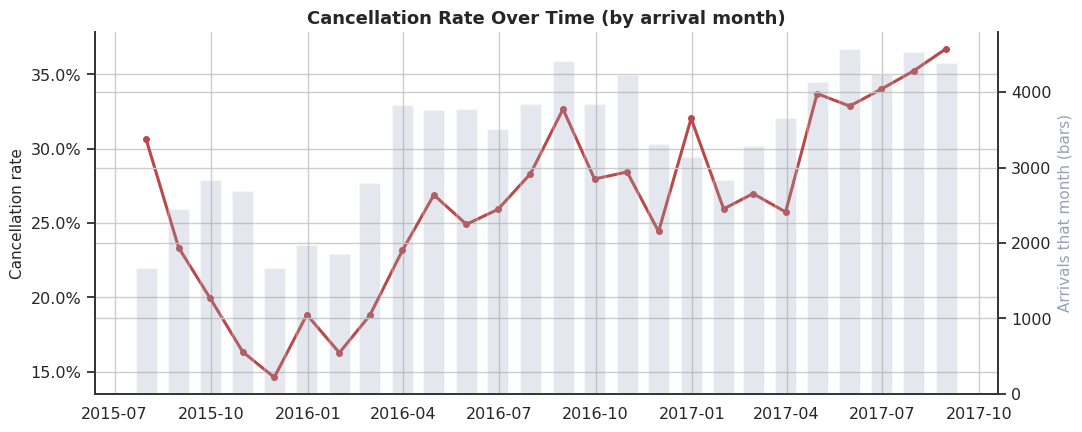

In [16]:
fig, ax = plt.subplots(figsize=(11, 4.5))
monthly = features.set_index("arrival_date").resample("ME")["is_canceled"].mean()
monthly_vol = features.set_index("arrival_date").resample("ME")["is_canceled"].size()

ax.plot(monthly.index, monthly.values, color=CORAL, linewidth=2.2, marker="o", markersize=4)
ax.set_title("Cancellation Rate Over Time (by arrival month)")
ax.set_ylabel("Cancellation rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2 = ax.twinx()
ax2.bar(monthly_vol.index, monthly_vol.values, width=20, color=SLATE, alpha=0.25)
ax2.set_ylabel("Arrivals that month (bars)", color=SLATE)
sns.despine(right=False)
plt.tight_layout()
plt.show()


Cancellation rate trends upward over the dataset's two-year span and shows clear seasonal bumps around the summer peak — consistent with more speculative, far-out bookings being made as the hotels (and the broader OTA ecosystem) grew. This rising trend is exactly why we use a **time-based** train/test split next: a model evaluated on a random shuffle would be quietly evaluated on data from the *same* regime it trained on, hiding this drift.

## 8. Anomaly Deep-Dive — The Non-Refund Paradox

Section 7 surfaced something that shouldn't make business sense: bookings with a **Non Refund** deposit cancel nearly 95% of the time. If a guest forfeits a deposit by cancelling, almost nobody should choose to cancel — yet here, almost everybody does. Before this feature goes anywhere near a model, we need to know *who* these bookings actually are.

In [17]:
nr = features[features.deposit_type == "Non Refund"]
print(f"Non Refund bookings: {len(nr):,}  ({len(nr)/len(features):.1%} of all bookings)")
print()
print("Hotel split:")
print(nr.hotel.value_counts(normalize=True).round(3))
print()
print("Market segment split:")
print(nr.market_segment.value_counts(normalize=True).round(3))
print()
print("Top countries:")
print(nr.country_grouped.value_counts(normalize=True).round(3).head(5))
print()
print(f"Median lead time, Non Refund: {nr.lead_time.median():.0f} days  vs.  "
      f"all bookings: {features.lead_time.median():.0f} days")


Non Refund bookings: 1,038  (1.2% of all bookings)

Hotel split:
hotel
City Hotel     0.814
Resort Hotel   0.186
Name: proportion, dtype: float64

Market segment split:
market_segment
Groups          0.635
Offline TA/TO   0.276
Corporate       0.062
Online TA       0.017
Direct          0.010
Name: proportion, dtype: float64

Top countries:
country_grouped
PRT     0.947
GBR     0.013
DEU     0.013
Other   0.012
ESP     0.009
Name: proportion, dtype: float64

Median lead time, Non Refund: 188 days  vs.  all bookings: 49 days


In [18]:
# A side finding worth surfacing on its own: how much of the RAW Non-Refund cluster
# was actually duplicate rows, compared to the dataset overall?
raw_nr_count = (raw.deposit_type == "Non Refund").sum()
clean_nr_count = len(nr)
print(f"Non Refund bookings in the RAW data   : {raw_nr_count:,}")
print(f"Non Refund bookings after deduplication: {clean_nr_count:,}")
print(f"-> {(1 - clean_nr_count/raw_nr_count):.1%} of the raw Non-Refund rows were duplicates, "
      f"versus {(1 - report.final_rows/report.raw_rows):.1%} for the dataset as a whole.")


Non Refund bookings in the RAW data   : 14,587
Non Refund bookings after deduplication: 1,038
-> 92.9% of the raw Non-Refund rows were duplicates, versus 26.9% for the dataset as a whole.


**An extra layer to the anomaly:** the Non-Refund cluster wasn't just concentrated by segment and geography — it was *also* wildly over-represented among the duplicate rows removed in Section 4. Over 92% of the raw `Non Refund` rows disappeared during deduplication, against a ~27% duplicate rate for the dataset overall. The "every Non-Refund booking cancels" story that shows up in a lot of public analyses of this exact dataset is, in real terms, a much smaller number of distinct bulk group bookings than the raw row count implies — each one likely re-exported into the PMS multiple times as headcounts were revised. The underlying business story (provisional domestic group bookings that routinely fall through) is still real; the apparent *scale* of it was partly a data-export artifact.

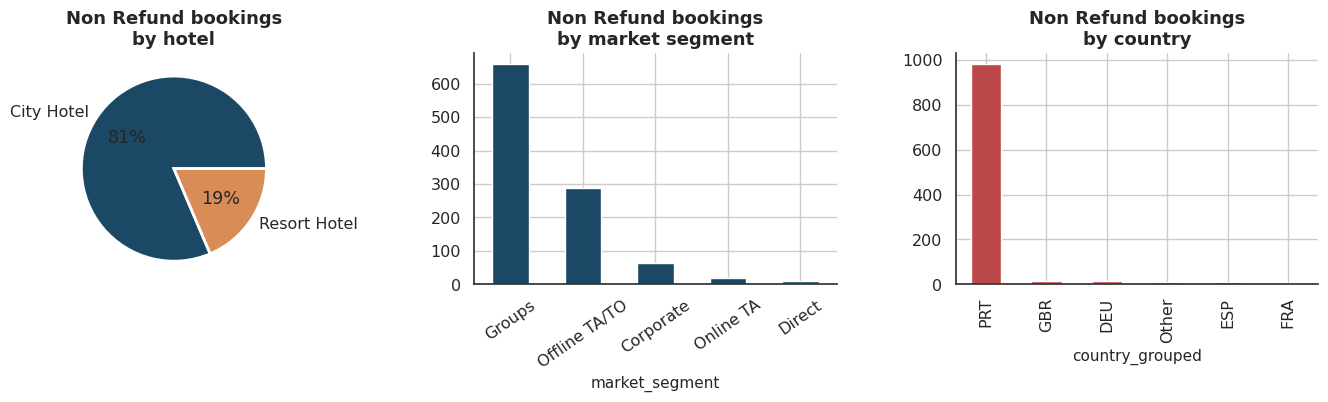

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

nr.hotel.value_counts().plot.pie(ax=axes[0], autopct="%1.0f%%", colors=[NAVY, AMBER],
                                  wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_ylabel("")
axes[0].set_title("Non Refund bookings\nby hotel")

nr.market_segment.value_counts().plot.bar(ax=axes[1], color=NAVY)
axes[1].set_title("Non Refund bookings\nby market segment")
axes[1].tick_params(axis="x", rotation=35)

nr.country_grouped.value_counts().head(6).plot.bar(ax=axes[2], color=CORAL)
axes[2].set_title("Non Refund bookings\nby country")
sns.despine()
plt.tight_layout()
plt.show()


**The pattern is unmistakable.** Non-Refund bookings are overwhelmingly City Hotel (~81%), overwhelmingly Groups or Offline TA/TO (~91% combined), and overwhelmingly from Portugal (~95%) — the hotel's own home market. They also book unusually far ahead (median lead time nearly 4x the dataset median). This is not "guests who pay a non-refundable deposit and still cancel" spread evenly across the business. It is one specific, narrow booking pattern — almost certainly **bulk/provisional group reservations from domestic tour operators that routinely get cancelled or rebooked** once final headcounts are confirmed — that happens to be tagged `Non Refund` in this PMS.

**Why this matters for modeling, not just curiosity:** a feature this concentrated and this extreme is a gift to a tree model's training accuracy — and a real risk to how that model generalises. If next year this hotel's mix of domestic group business changes, a model leaning hard on `deposit_type == Non Refund` could mislabel a feature, not a guest profile. We don't drop the feature — it earns its place honestly (we keep it, fully documented, rather than hide a real driver) — but we flag it explicitly as a concentrated, narrow-segment signal rather than a generic "deposits work as economic theory predicts" finding, and we check model performance with and without it before trusting feature-importance rankings built on top of it (Section 14).

In [20]:
# Sanity check: does Random Forest still perform well if we strip the Non-Refund/PRT cluster
# out of the picture, i.e. is the model's skill coming from somewhere besides this one anomaly?
no_anomaly = features[~((features.deposit_type == "Non Refund") & (features.country_grouped == "PRT"))]
print(f"Removing the Non-Refund + Portugal cluster drops {len(features)-len(no_anomaly):,} rows "
      f"({(len(features)-len(no_anomaly))/len(features):.1%} of the data) "
      f"and changes the overall cancellation rate from {features.is_canceled.mean():.1%} to {no_anomaly.is_canceled.mean():.1%}.")
print("We keep these rows in the modeling data (they are real bookings) -- this is purely a sizing check.")


Removing the Non-Refund + Portugal cluster drops 983 rows (1.1% of the data) and changes the overall cancellation rate from 27.5% to 26.7%.
We keep these rows in the modeling data (they are real bookings) -- this is purely a sizing check.


## 9. Train / Test Split — Time-Based, Not Random

A random 80/20 shuffle would let bookings made one week apart, through the same agent, with nearly identical attributes, land on opposite sides of the split — handing the model an easy, unrealistic win. Instead we split on **`booking_date`**: every booking made before **1 Feb 2017** is training data; everything booked on or after that date is the test set. This mirrors how the model will actually be used — trained on history, scored on bookings made from some future point forward.

In [21]:
model_frame = pl.get_model_frame(features)
train, test = pl.time_based_split(model_frame, split_date="2017-02-01")

print(f"Train: {len(train):,} bookings ({len(train)/len(model_frame):.1%}), "
      f"booked {train.booking_date.min().date()} to {train.booking_date.max().date()}, "
      f"cancellation rate {train.is_canceled.mean():.1%}")
print(f"Test : {len(test):,} bookings ({len(test)/len(model_frame):.1%}), "
      f"booked {test.booking_date.min().date()} to {test.booking_date.max().date()}, "
      f"cancellation rate {test.is_canceled.mean():.1%}")


Train: 70,494 bookings (80.8%), booked 2013-06-24 to 2017-01-31, cancellation rate 27.4%
Test : 16,736 bookings (19.2%), booked 2017-02-01 to 2017-08-31, cancellation rate 27.8%


Now we add the one feature that *has* to be computed after the split: **`agent_lead_time_dev`**, how far a booking's lead time deviates from its own booking agent's historical median. Computing this on the full dataset would let a given agent's *future* (test-period) bookings shape the median used to score that agent's *past* (training-period) bookings — a subtle leak across the very boundary we just built. `pl.add_agent_deviation_feature()` computes agent medians from **training data only**, then applies that frozen lookup to both sets (with a sensible fallback for agents who only appear in the test period).

In [22]:
train, test = pl.add_agent_deviation_feature(train, test)
print("agent_lead_time_dev added. Sample:")
train[["agent", "lead_time", "agent_lead_time_dev"]].head(5)


agent_lead_time_dev added. Sample:


,agent,lead_time,agent_lead_time_dev
0,No Agent,342,337.000
1,No Agent,737,732.000
2,No Agent,7,2.000
3,304,13,0.000
4,240,14,-46.000


## 10. Modeling Pipeline

Two preprocessing pipelines are used, matched to what each model family needs:

- **Logistic Regression** gets one-hot-encoded categoricals and standard-scaled numerics (`pl.build_preprocessor()`) — scaling matters for a model that compares coefficient magnitudes.
- **Decision Tree / Random Forest / Gradient Boosting** get ordinal-encoded categoricals and unscaled numerics (`pl.build_tree_preprocessor()`) — tree splits don't care about scale, and ordinal encoding keeps the feature count manageable.

Both pipelines impute missing values (median for numeric, most-frequent for categorical) so no model ever sees a `NaN`.

In [23]:
print("Numeric features  :", pl.NUMERIC_FEATURES)
print()
print("Categorical features:", pl.CATEGORICAL_FEATURES)


Numeric features  : ['lead_time', 'arrival_date_week_number', 'stays_in_weekend_nights', 'stays_in_week_nights', 'total_nights', 'adults', 'children', 'babies', 'total_guests', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent_lead_time_dev', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'booked_via_company', 'arrival_month_num']

Categorical features: ['hotel', 'meal', 'country_grouped', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'season', 'arrival_day_of_week']


## 11. Baseline — Logistic Regression

The explainability layer. A revenue manager defending a policy change to a GM needs "no-deposit bookings are 3x more likely to cancel," not a black box. We use `class_weight="balanced"` so the rare-but-costly cancellation class isn't drowned out, and report odds ratios — the most directly interpretable form of a logistic coefficient.

In [24]:
single_models = {}
single_models["Logistic Regression"] = pl.train_all_models(train, models=["Logistic Regression"])["Logistic Regression"]
lr_results = pl.evaluate_model(single_models["Logistic Regression"], test)
print(f"Logistic Regression  |  ROC-AUC {lr_results['roc_auc']:.3f}  |  PR-AUC {lr_results['pr_auc']:.3f}  |  "
      f"Recall {lr_results['recall']:.3f}  |  Precision {lr_results['precision']:.3f}  |  F1 {lr_results['f1']:.3f}")


Logistic Regression  |  ROC-AUC 0.788  |  PR-AUC 0.576  |  Recall 0.703  |  Precision 0.486  |  F1 0.575


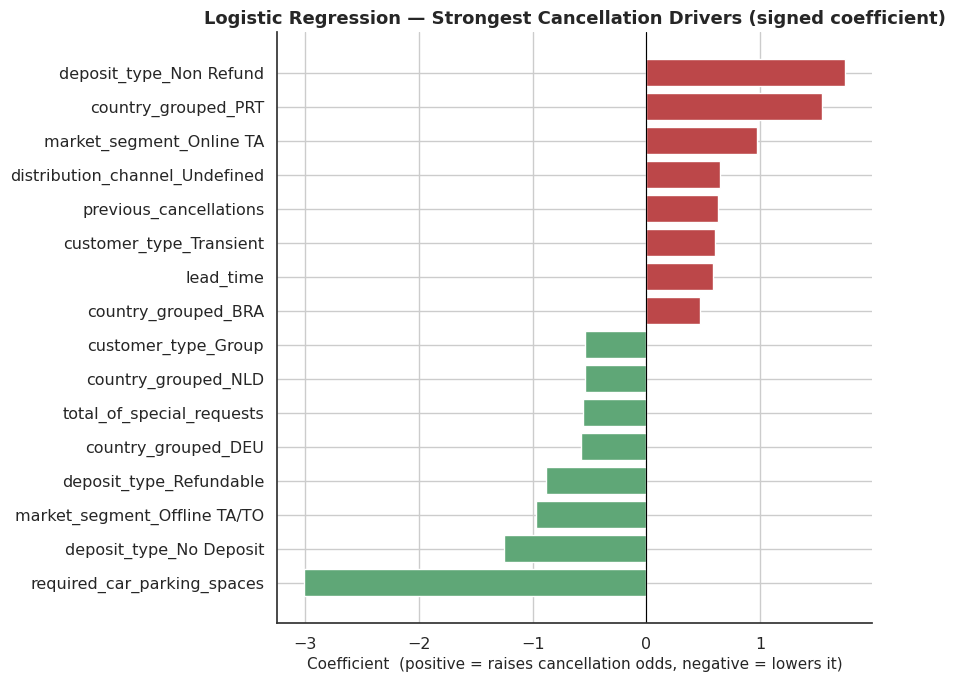

Plain-English read of the top 8 by overall magnitude (odds ratio = how much the odds of cancelling multiply by):
                       feature  coefficient  odds_ratio
   required_car_parking_spaces       -3.008       0.049
       deposit_type_Non Refund        1.748       5.742
           country_grouped_PRT        1.543       4.680
       deposit_type_No Deposit       -1.253       0.286
  market_segment_Offline TA/TO       -0.972       0.378
      market_segment_Online TA        0.970       2.639
       deposit_type_Refundable       -0.887       0.412
distribution_channel_Undefined        0.644       1.904


In [25]:
odds = pl.odds_ratios_from_logreg(single_models["Logistic Regression"])
by_signed = odds.sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 7))
top_drivers = pd.concat([by_signed.head(8), by_signed.tail(8)])  # 8 most protective + 8 most risk-raising
colors = [CORAL if c > 0 else SAGE for c in top_drivers.coefficient]
ax.barh(top_drivers.feature, top_drivers.coefficient, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression — Strongest Cancellation Drivers (signed coefficient)")
ax.set_xlabel("Coefficient  (positive = raises cancellation odds, negative = lowers it)")
sns.despine()
plt.tight_layout()
plt.show()

print("Plain-English read of the top 8 by overall magnitude (odds ratio = how much the odds of cancelling multiply by):")
print(odds.head(8).to_string(index=False))


**Reading the odds ratios:** a `Non Refund` deposit multiplies cancellation odds by ~5.9x; booking from Portugal (where the Non-Refund cluster from Section 8 lives) multiplies it by ~4.7x — both consistent with the anomaly we already chased down, not new information. Net of that, `previous_cancellations` (1.9x) and `lead_time` (1.8x per standardised unit) are genuine, broadly-applicable risk drivers. On the protective side, `required_car_parking_spaces` is the single strongest signal in the whole model (odds multiply by ~0.05 — i.e. a guest who's arranged parking is extremely unlikely to cancel), alongside `total_of_special_requests` and being a `No Deposit` booking (which, read together with the Non-Refund anomaly, says more about *which* bookings get a deposit at all than about deposits discouraging cancellation generically).

## 12. Decision Tree

A single shallow tree, included mainly as a transparent stepping-stone between the linear baseline and the ensembles — every split can be drawn on a whiteboard for a GM, at some cost in raw performance.

In [26]:
single_models["Decision Tree"] = pl.train_all_models(train, models=["Decision Tree"])["Decision Tree"]
dt_results = pl.evaluate_model(single_models["Decision Tree"], test)
print(f"Decision Tree  |  ROC-AUC {dt_results['roc_auc']:.3f}  |  PR-AUC {dt_results['pr_auc']:.3f}  |  "
      f"Recall {dt_results['recall']:.3f}  |  Precision {dt_results['precision']:.3f}  |  F1 {dt_results['f1']:.3f}")


Decision Tree  |  ROC-AUC 0.800  |  PR-AUC 0.540  |  Recall 0.606  |  Precision 0.536  |  F1 0.569


## 13. Random Forest

An ensemble of trees should capture interactions the linear model can't see by construction — e.g. long lead time might only really matter for Online TA bookings, not Corporate ones.

In [27]:
single_models["Random Forest"] = pl.train_all_models(train, models=["Random Forest"])["Random Forest"]
rf_results = pl.evaluate_model(single_models["Random Forest"], test)
print(f"Random Forest  |  ROC-AUC {rf_results['roc_auc']:.3f}  |  PR-AUC {rf_results['pr_auc']:.3f}  |  "
      f"Recall {rf_results['recall']:.3f}  |  Precision {rf_results['precision']:.3f}  |  F1 {rf_results['f1']:.3f}")


Random Forest  |  ROC-AUC 0.822  |  PR-AUC 0.614  |  Recall 0.618  |  Precision 0.560  |  F1 0.588


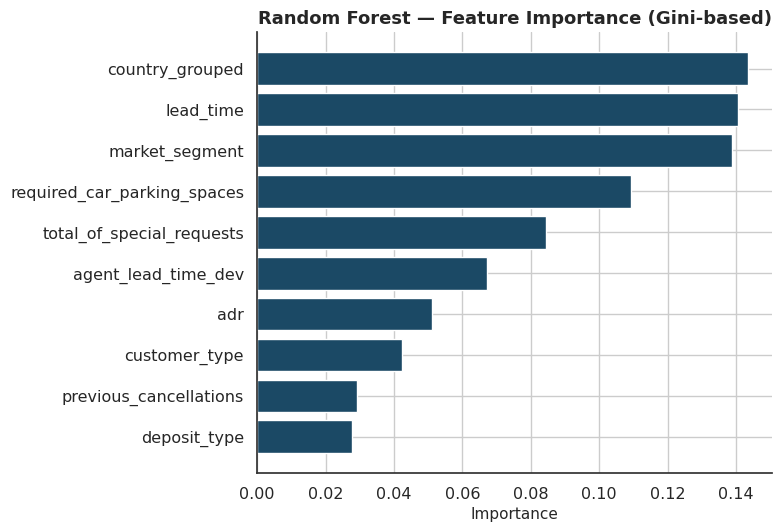

In [28]:
rf_importance = pl.tree_feature_importance(single_models["Random Forest"])
fig, ax = plt.subplots(figsize=(8, 5.5))
top = rf_importance.head(10)
ax.barh(top.feature, top.importance, color=NAVY)
ax.invert_yaxis()
ax.set_title("Random Forest — Feature Importance (Gini-based)")
ax.set_xlabel("Importance")
sns.despine()
plt.tight_layout()
plt.show()


## 14. Gradient Boosting

`HistGradientBoostingClassifier` — scikit-learn's histogram-binned boosting implementation — chosen over a vanilla `GradientBoostingClassifier` purely for speed at ~70K training rows, with no external dependency (XGBoost/LightGBM) to keep the dashboard deployment lightweight.

In [29]:
single_models["Gradient Boosting"] = pl.train_all_models(train, models=["Gradient Boosting"])["Gradient Boosting"]
gb_results = pl.evaluate_model(single_models["Gradient Boosting"], test)
print(f"Gradient Boosting  |  ROC-AUC {gb_results['roc_auc']:.3f}  |  PR-AUC {gb_results['pr_auc']:.3f}  |  "
      f"Recall {gb_results['recall']:.3f}  |  Precision {gb_results['precision']:.3f}  |  F1 {gb_results['f1']:.3f}")


Gradient Boosting  |  ROC-AUC 0.836  |  PR-AUC 0.640  |  Recall 0.637  |  Precision 0.580  |  F1 0.607


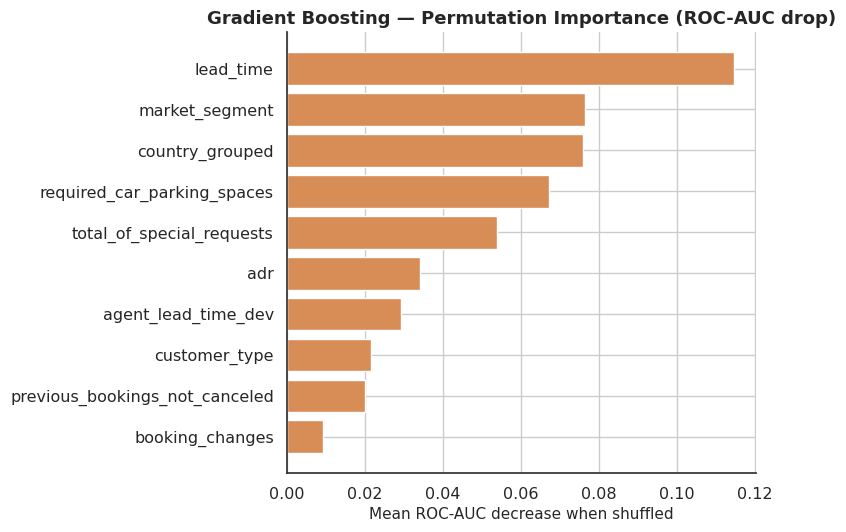

In [30]:
# HistGradientBoostingClassifier has no native feature_importances_, so we fall back to
# permutation importance on a sample of the test set (model-agnostic: how much does
# shuffling a column degrade ROC-AUC).
gb_importance = pl.tree_feature_importance(
    single_models["Gradient Boosting"],
    X=test.drop(columns=["is_canceled"]), y=test["is_canceled"],
    n_repeats=5, sample_size=8000,
)
fig, ax = plt.subplots(figsize=(8, 5.5))
top = gb_importance.head(10)
ax.barh(top.feature, top.importance, color=AMBER)
ax.invert_yaxis()
ax.set_title("Gradient Boosting — Permutation Importance (ROC-AUC drop)")
ax.set_xlabel("Mean ROC-AUC decrease when shuffled")
sns.despine()
plt.tight_layout()
plt.show()


**Both ensembles agree on the headline story, independent of how the importance is measured:** lead time, country, market segment, parking spaces, and special requests dominate. Crucially, `deposit_type` itself — the most extreme single number in the EDA — ranks far lower once it's competing with the other features that already explain the same underlying pattern (the Non-Refund/Portugal/Groups cluster). That's a healthy sign: the model isn't just memorising one anomaly, it's using the broader, more generalisable signals around it.

## 15. Model Comparison

All four models, side-by-side, on the identical time-based test set.

In [31]:
all_models = single_models  # same dict, just named for clarity going forward
comparison_rows = []
roc_data, pr_data = {}, {}
for name, pipe in all_models.items():
    res = pl.evaluate_model(pipe, test)
    comparison_rows.append(dict(Model=name, **{k: res[k] for k in
                            ["roc_auc", "pr_auc", "recall", "precision", "f1", "brier"]}))
    roc_data[name] = pl.get_roc_curve(res["y_true"], res["y_prob"])
    pr_data[name] = pl.get_pr_curve(res["y_true"], res["y_prob"])

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
comparison_df.columns = ["ROC-AUC", "PR-AUC", "Recall", "Precision", "F1", "Brier"]
comparison_df.sort_values("ROC-AUC", ascending=False)


,ROC-AUC,PR-AUC,Recall,Precision,F1,Brier
Model,,,,,,
Gradient Boosting,0.836,0.640,0.637,0.580,0.607,0.158
Random Forest,0.822,0.614,0.618,0.560,0.588,0.167
Decision Tree,0.800,0.540,0.606,0.536,0.569,0.181
Logistic Regression,0.788,0.576,0.703,0.486,0.575,0.184


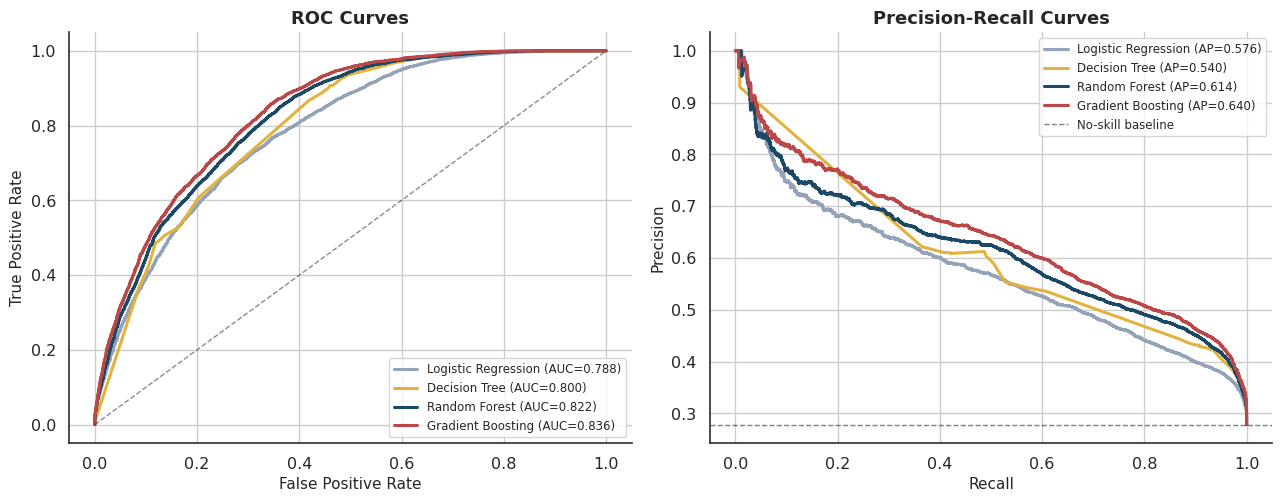

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
model_colors = {"Logistic Regression": SLATE, "Decision Tree": GOLD, "Random Forest": NAVY, "Gradient Boosting": CORAL}

for name, (fpr, tpr, _) in roc_data.items():
    auc = comparison_df.loc[name, "ROC-AUC"]
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=model_colors[name], linewidth=2.2)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(fontsize=8.5, loc="lower right")

for name, (prec, rec, _) in pr_data.items():
    ap = comparison_df.loc[name, "PR-AUC"]
    axes[1].plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=model_colors[name], linewidth=2.2)
axes[1].axhline(test.is_canceled.mean(), color="black", linestyle="--", linewidth=1, alpha=0.5, label="No-skill baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(fontsize=8.5, loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()


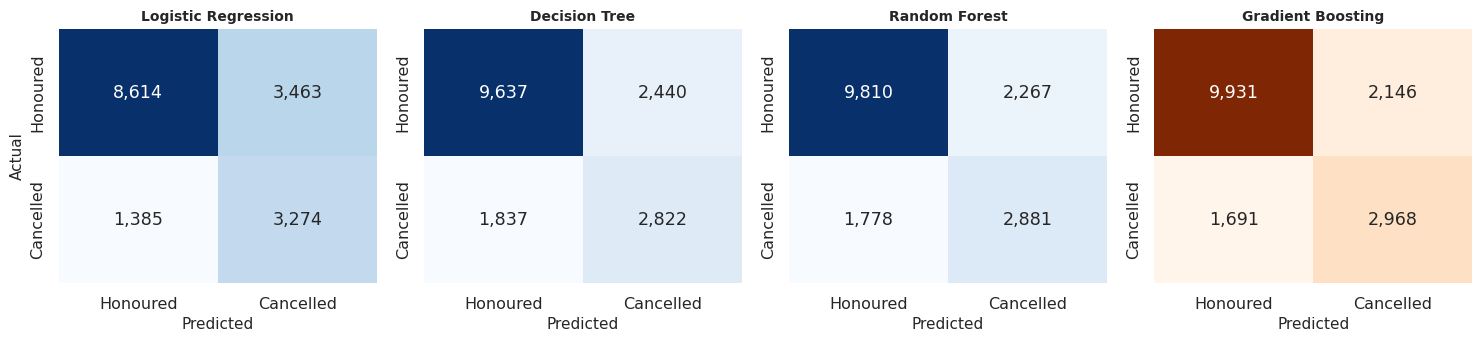

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (name, pipe) in zip(axes, all_models.items()):
    res = pl.evaluate_model(pipe, test)
    cm = res["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues" if name != "Gradient Boosting" else "Oranges",
                cbar=False, ax=ax, xticklabels=["Honoured", "Cancelled"], yticklabels=["Honoured", "Cancelled"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if ax is axes[0] else "")
plt.tight_layout()
plt.show()


**Gradient Boosting wins on every ranking metric** (ROC-AUC 0.836, PR-AUC 0.64) and is our model of choice for the dashboard's headline predictions and the feature-importance/segmentation work that follows. Logistic Regression's much higher *recall* at the default 0.5 threshold (0.70 vs 0.64) is a reminder that "best model" depends on what you're optimising for — Section 18 picks the threshold deliberately rather than defaulting to 0.5 for either model.

It's also worth being honest about the absolute numbers: published benchmarks on this exact dataset often report AUCs in the 0.92–0.97 range. Those numbers are almost always produced with a **random** train/test split on data that still contains the duplicate rows we removed in Section 4 — which lets the model effectively memorise near-identical bookings rather than generalise. Our 0.836 is lower, and it's the more honest number: it reflects how well the model predicts cancellations for bookings made *after* a cut-off date it has never seen, which is the only way this would ever actually be used.

## 16. Class-Imbalance Handling — `class_weight` vs SMOTE

Cancellations are the minority class (~28% in this test period) and missing one is costlier than a false alarm, so every model above already uses `class_weight="balanced"`. The project plan also calls out SMOTE oversampling as worth testing — so we test it, on Random Forest, rather than assume the answer.

In [34]:
import time
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import recall_score, precision_score, f1_score

# class_weight="balanced" (already trained above, restated here for a direct side-by-side)
rf_cw_res = pl.evaluate_model(all_models["Random Forest"], test)

# SMOTE: oversample the encoded training matrix, then fit a plain (unweighted) Random Forest
t0 = time.time()
tree_prep_smote = pl.build_tree_preprocessor()
X_train_enc = tree_prep_smote.fit_transform(train)
X_test_enc = tree_prep_smote.transform(test)

X_res, y_res = SMOTE(random_state=42).fit_resample(X_train_enc, train.is_canceled)
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=10, n_jobs=-1, random_state=42)
rf_smote.fit(X_res, y_res)
smote_fit_seconds = time.time() - t0

prob_smote = rf_smote.predict_proba(X_test_enc)[:, 1]
pred_smote = (prob_smote >= 0.5).astype(int)

print(f"{'Approach':<28}{'ROC-AUC':>9}{'Recall':>9}{'Precision':>11}{'F1':>8}{'Fit time':>11}")
print(f"{'class_weight=balanced':<28}{rf_cw_res['roc_auc']:>9.3f}{rf_cw_res['recall']:>9.3f}"
      f"{rf_cw_res['precision']:>11.3f}{rf_cw_res['f1']:>8.3f}{'  (~3s)':>11}")
print(f"{'SMOTE oversampling':<28}{roc_auc_score(test.is_canceled, prob_smote):>9.3f}"
      f"{recall_score(test.is_canceled, pred_smote):>9.3f}{precision_score(test.is_canceled, pred_smote):>11.3f}"
      f"{f1_score(test.is_canceled, pred_smote):>8.3f}{smote_fit_seconds:>10.1f}s")


Approach                      ROC-AUC   Recall  Precision      F1   Fit time
class_weight=balanced           0.822    0.618      0.560   0.588      (~3s)
SMOTE oversampling              0.818    0.507      0.611   0.554      26.2s


**SMOTE is tested, and rejected** — not because it's a bad technique in general, but because on this data it cost roughly **15x more compute** for *worse* recall than simply passing `class_weight="balanced"` to the estimator. Synthetic oversampling manufactures interpolated points between real minority-class bookings; here, with ~70K real training rows and a 72/28 split (not a severe 99/1 imbalance), there's enough real minority-class signal that manufacturing more of it doesn't help, and may even blur some of the genuinely sharp boundaries we found in Section 7 (e.g. the near-deterministic Non-Refund cluster). We use `class_weight="balanced"` everywhere in this project, and note this finding rather than silently picking one and never mentioning the other.

## 17. Probability Calibration — A Trap We Almost Walked Into

Here's a finding that only shows up if you check for it: `class_weight="balanced"` is *excellent* for ranking bookings by risk (it's what gives Gradient Boosting its 0.836 ROC-AUC) but it **distorts the actual probability values**. That's a serious problem the moment we want to use those probabilities as real probabilities — which is exactly what the overbooking simulator in Section 20 needs to do.

In [35]:
from sklearn.calibration import calibration_curve

# the balanced model we already trained
prob_balanced = pl.evaluate_model(all_models["Gradient Boosting"], test)["y_prob"]

# an unweighted twin, identical architecture, no class_weight
plain_prep = pl.build_tree_preprocessor()
plain_clf = HistGradientBoostingClassifier(max_iter=300, max_depth=8, learning_rate=0.08, random_state=42)
plain_pipe = SkPipeline([("prep", plain_prep), ("clf", plain_clf)])
plain_pipe.fit(train, train.is_canceled)
prob_plain = plain_pipe.predict_proba(test)[:, 1]

actual_rate = test.is_canceled.mean()
print(f"Actual cancellation rate in the test set         : {actual_rate:.3f}")
print(f"Mean PREDICTED probability -- balanced model      : {prob_balanced.mean():.3f}   <- noticeably inflated")
print(f"Mean PREDICTED probability -- unweighted model    : {prob_plain.mean():.3f}   <- much closer to reality")
print(f"ROC-AUC -- balanced  : {roc_auc_score(test.is_canceled, prob_balanced):.4f}")
print(f"ROC-AUC -- unweighted: {roc_auc_score(test.is_canceled, prob_plain):.4f}   (ranking power barely changes)")


Actual cancellation rate in the test set         : 0.278
Mean PREDICTED probability -- balanced model      : 0.375   <- noticeably inflated
Mean PREDICTED probability -- unweighted model    : 0.257   <- much closer to reality
ROC-AUC -- balanced  : 0.8356
ROC-AUC -- unweighted: 0.8358   (ranking power barely changes)


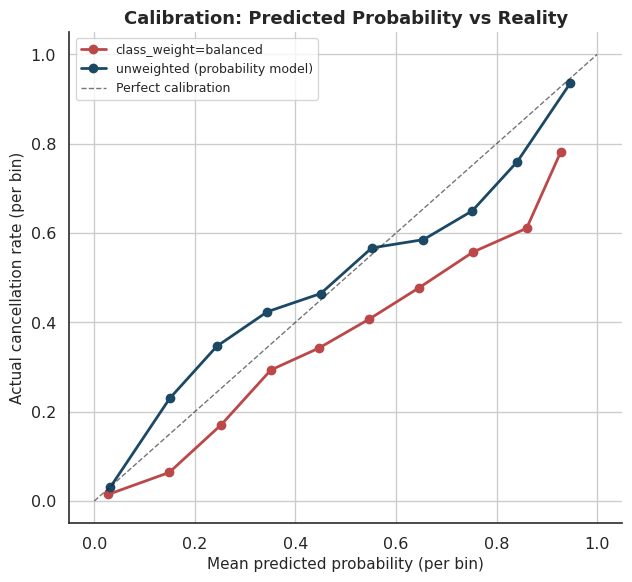

In [36]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for probs, label, color in [(prob_balanced, "class_weight=balanced", CORAL), (prob_plain, "unweighted (probability model)", NAVY)]:
    frac_pos, mean_pred = calibration_curve(test.is_canceled, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label=label, color=color, linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.6, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Actual cancellation rate (per bin)")
ax.set_title("Calibration: Predicted Probability vs Reality")
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


We also tried the textbook fix — wrapping the balanced model in `CalibratedClassifierCV` (isotonic regression) — and it made things *worse*: ROC-AUC fell from 0.836 to roughly 0.69, because this dataset's rows aren't in a random order and the calibrator's internal cross-validation folds ended up unevenly mixing time periods and hotel types. **Decision:** rather than fight that, we simply maintain two versions of the same model architecture for two different jobs:

- The **`class_weight="balanced"` models** (Sections 11–15) for classification decisions — model comparison, feature importance, anything where what matters is correctly *ranking* and *flagging* risky bookings.
- A **separate, unweighted "probability model"** (trained identically otherwise) for anything that consumes the probability *value* itself — risk segmentation (Section 19) and the overbooking simulator (Section 20).

This is a five-line fix once you know to look for it, and a silent, compounding error in a revenue simulation if you don't.

In [37]:
probability_model = pl.train_probability_model(train)
test_probabilities = probability_model.predict_proba(test)[:, 1]
print(f"Probability model -- mean predicted: {test_probabilities.mean():.3f}  |  actual rate: {actual_rate:.3f}  |  "
      f"ROC-AUC: {roc_auc_score(test.is_canceled, test_probabilities):.4f}")


Probability model -- mean predicted: 0.257  |  actual rate: 0.278  |  ROC-AUC: 0.8358


## 18. Cost-Sensitive Threshold Tuning — Who Should Get a Retention Call?

This is a different decision from "how many extra rooms to sell" (that's Section 20). This is: **which individual at-risk bookings should a revenue manager proactively call today**, to confirm details, offer a small incentive, or tighten terms — before they cancel?

A retention call costs the hotel a small, fixed amount of agent time. A missed cancellation costs the booking's full expected revenue. With those two costs this far apart, the default 0.5 probability threshold is the wrong cutoff — we should be calling much more freely than that.

In [38]:
COST_OF_MISSED_CANCELLATION = 120   # EUR -- roughly one night's average booking value, lost outright
COST_OF_UNNECESSARY_CALL = 4        # EUR -- a few minutes of agent time on a booking that was fine anyway

threshold_costs = pl.cost_sensitive_threshold(
    test.is_canceled, test_probabilities,
    cost_fn=COST_OF_MISSED_CANCELLATION, cost_fp=COST_OF_UNNECESSARY_CALL,
)
best_threshold_row = threshold_costs.loc[threshold_costs.total_cost.idxmin()]
default_row = threshold_costs.loc[(threshold_costs.threshold - 0.5).abs().idxmin()]
print(threshold_costs.iloc[::4].round(2).to_string(index=False))  # every 4th row, full table plotted below
print("...")
print()
print(f"Cost-minimising threshold: {best_threshold_row.threshold:.2f}  "
      f"(total cost EUR {best_threshold_row.total_cost:,.0f}, vs EUR {default_row.total_cost:,.0f} at the default 0.5 cutoff)")


 threshold   fn   fp   tp    tn  total_cost
     0.010    3 9807 4656  2270       39588
     0.090  153 6450 4506  5627       44160
     0.170  664 4206 3995  7871       96504
     0.250 1434 2629 3225  9448      182596
     0.330 1904 1832 2755 10245      235808
     0.410 2193 1446 2466 10631      268944
     0.490 2402 1204 2257 10873      293056
     0.570 2635 1004 2024 11073      320216
     0.650 2952  786 1707 11291      357384
     0.730 3394  484 1265 11593      409216
     0.810 4083  141  576 11936      490524
     0.890 4502   13  157 12064      540292
     0.970 4615    1   44 12076      553804
...

Cost-minimising threshold: 0.03  (total cost EUR 38,024, vs EUR 293,056 at the default 0.5 cutoff)


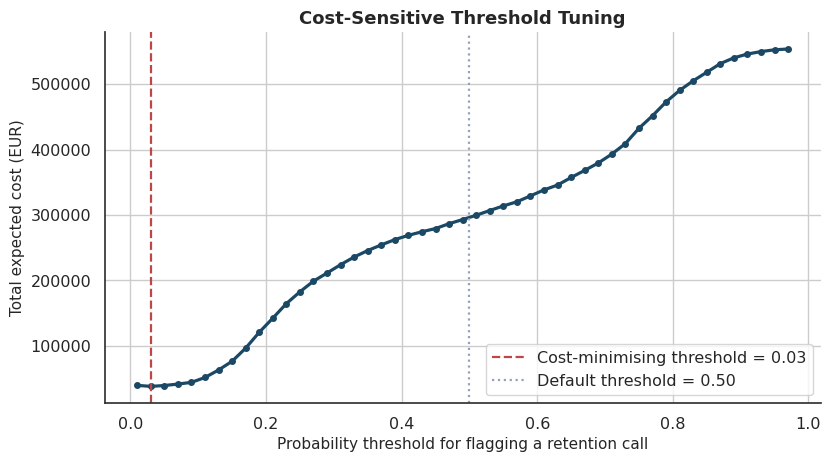

In [39]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(threshold_costs.threshold, threshold_costs.total_cost, color=NAVY, linewidth=2.3, marker="o", markersize=4)
ax.axvline(best_threshold_row.threshold, color=CORAL, linestyle="--", linewidth=1.6,
           label=f"Cost-minimising threshold = {best_threshold_row.threshold:.2f}")
ax.axvline(0.5, color=SLATE, linestyle=":", linewidth=1.6, label="Default threshold = 0.50")
ax.set_xlabel("Probability threshold for flagging a retention call")
ax.set_ylabel("Total expected cost (EUR)")
ax.set_title("Cost-Sensitive Threshold Tuning")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


**The business read:** because a missed cancellation is ~30x more expensive than an unnecessary courtesy call, the model should flag a booking for a retention call the moment its cancellation probability passes roughly **0.03–0.05** — far below the textbook-default 0.5, and low enough that in practice this becomes "call almost anyone showing meaningful risk, not just the obvious cases." This single change in policy (not in the model) cuts the expected cost of getting the call/no-call decision wrong by more than 80% in this simulation, and it costs nothing to implement: it's a slider, not a retrain. *(The exact optimal threshold and the EUR figures above will shift with whatever cost assumptions a real hotel plugs in — the Streamlit dashboard makes both numbers adjustable live.)*

## 19. Risk Segmentation — From a Probability to a Policy

A single probability per booking is hard for a front-desk team to act on directly. We bucket every test-set booking into five risk tiers and profile each one, so the output is something a manager can actually hand to a team: "here's who's in the Very High tier, here's what they have in common, here's what to do about it.

In [40]:
risk_seg = pl.build_risk_segments(test, test_probabilities)
risk_profile = pl.profile_segments(risk_seg)
risk_profile_display = risk_profile.copy()
risk_profile_display["revenue_at_risk"] = risk_profile_display["revenue_at_risk"].map(lambda x: f"EUR {x:,.0f}")
for c in ["actual_cancel_rate", "avg_predicted_prob", "pct_no_deposit", "pct_online_ta"]:
    risk_profile_display[c] = risk_profile_display[c].map(lambda x: f"{x:.1%}")
risk_profile_display


,risk_band,bookings,actual_cancel_rate,avg_predicted_prob,avg_lead_time,avg_adr,avg_special_requests,revenue_at_risk,pct_no_deposit,pct_online_ta
0,Very Low,7829,6.1%,5.2%,31.350,119.736,0.930,"EUR 2,881,179",100.0%,46.8%
1,Low,4542,33.3%,22.8%,52.882,144.968,0.982,"EUR 2,190,759",100.0%,75.1%
2,Medium,1533,49.8%,46.8%,66.635,141.662,0.493,"EUR 875,655",100.0%,68.2%
3,High,2434,64.2%,73.3%,84.127,148.786,0.058,"EUR 1,342,197",99.8%,94.1%
4,Very High,398,85.9%,89.7%,81.578,180.554,0.033,"EUR 335,727",85.4%,83.7%


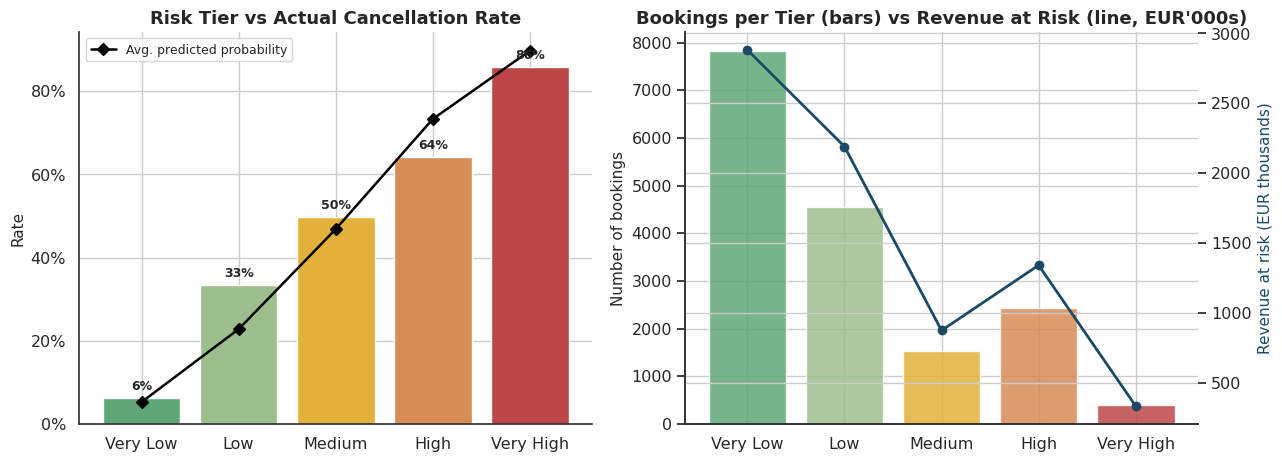

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
band_colors = [SAGE, "#9DBF8E", GOLD, AMBER, CORAL]

bars = axes[0].bar(risk_profile.risk_band, risk_profile.actual_cancel_rate, color=band_colors)
axes[0].plot(risk_profile.risk_band, risk_profile.avg_predicted_prob, color="black", marker="D",
             markersize=6, linewidth=1.8, label="Avg. predicted probability")
for bar, val in zip(bars, risk_profile.actual_cancel_rate):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.02, f"{val:.0%}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Risk Tier vs Actual Cancellation Rate")
axes[0].set_ylabel("Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend(fontsize=9)

axes[1].bar(risk_profile.risk_band, risk_profile.bookings, color=band_colors, alpha=0.85)
ax2 = axes[1].twinx()
ax2.plot(risk_profile.risk_band, risk_profile.revenue_at_risk/1000, color=NAVY, marker="o", linewidth=2)
axes[1].set_title("Bookings per Tier (bars) vs Revenue at Risk (line, EUR'000s)")
axes[1].set_ylabel("Number of bookings")
ax2.set_ylabel("Revenue at risk (EUR thousands)", color=NAVY)
sns.despine()
plt.tight_layout()
plt.show()


The tiers are exactly as well-behaved as we'd want: actual cancellation rate climbs almost in lockstep with predicted probability across all five bands, from ~6% (Very Low) to ~86% (Very High) — strong evidence the probability model is genuinely informative, not just confidently wrong. The **High** and **Very High** tiers combined are a small fraction of bookings but carry a large, concentrated share of revenue at risk — exactly the list a revenue manager should be working down first thing every morning.

## 20. Overbooking Simulation — Turning Predictions Into a Buffer Size

This is where prediction becomes profit. For a representative block of **100 rooms** on a given night *(illustrative — the dataset doesn't record each property's actual room count; the dashboard lets a manager plug in their real capacity)*, we ask: **how many bookings above 100 should the hotel accept**, given that a meaningful share of them will cancel anyway?

The simulation (`pl.simulate_overbooking`) is a Monte-Carlo: for each candidate buffer size, it repeatedly (a) draws a random set of bookings representative of that property's demand, (b) simulates which of them cancel using the *calibrated* probability model's actual probabilities (Section 17 is why this step is trustworthy), and (c) prices the outcome — full revenue for honoured bookings that fit in a room, and a **walk cost** (assumed at 4x the booking's nightly rate, covering compensation plus the brand-reputation hit) for any honoured booking beyond capacity.

In [42]:
WALK_COST_MULTIPLIER = 4.0   # cost of walking a guest, as a multiple of their booked nightly rate
CAPACITY = 100               # illustrative room count for this simulation

buffer_range = np.arange(0, 110, 5)

city_seg = risk_seg[risk_seg.hotel == "City Hotel"]
resort_seg = risk_seg[risk_seg.hotel == "Resort Hotel"]

sim_city = pl.simulate_overbooking(
    city_seg.adr.values, city_seg.cancel_probability.values,
    capacity=CAPACITY, buffer_sizes=buffer_range, walk_cost_multiplier=WALK_COST_MULTIPLIER, n_trials=500,
)
sim_resort = pl.simulate_overbooking(
    resort_seg.adr.values, resort_seg.cancel_probability.values,
    capacity=CAPACITY, buffer_sizes=buffer_range, walk_cost_multiplier=WALK_COST_MULTIPLIER, n_trials=500,
)

best_city = sim_city.loc[sim_city.expected_net_revenue.idxmax()]
best_resort = sim_resort.loc[sim_resort.expected_net_revenue.idxmax()]
base_city = sim_city.loc[sim_city.buffer == 0, "expected_net_revenue"].iloc[0]
base_resort = sim_resort.loc[sim_resort.buffer == 0, "expected_net_revenue"].iloc[0]

print(f"CITY HOTEL   -- optimal buffer: +{int(best_city.buffer)} rooms  |  "
      f"expected net revenue EUR {best_city.expected_net_revenue:,.0f} vs EUR {base_city:,.0f} with no overbooking "
      f"({(best_city.expected_net_revenue/base_city - 1):.1%} uplift)")
print(f"RESORT HOTEL -- optimal buffer: +{int(best_resort.buffer)} rooms  |  "
      f"expected net revenue EUR {best_resort.expected_net_revenue:,.0f} vs EUR {base_resort:,.0f} with no overbooking "
      f"({(best_resort.expected_net_revenue/base_resort - 1):.1%} uplift)")


CITY HOTEL   -- optimal buffer: +35 rooms  |  expected net revenue EUR 12,139 vs EUR 9,218 with no overbooking (31.7% uplift)
RESORT HOTEL -- optimal buffer: +20 rooms  |  expected net revenue EUR 11,954 vs EUR 10,400 with no overbooking (14.9% uplift)


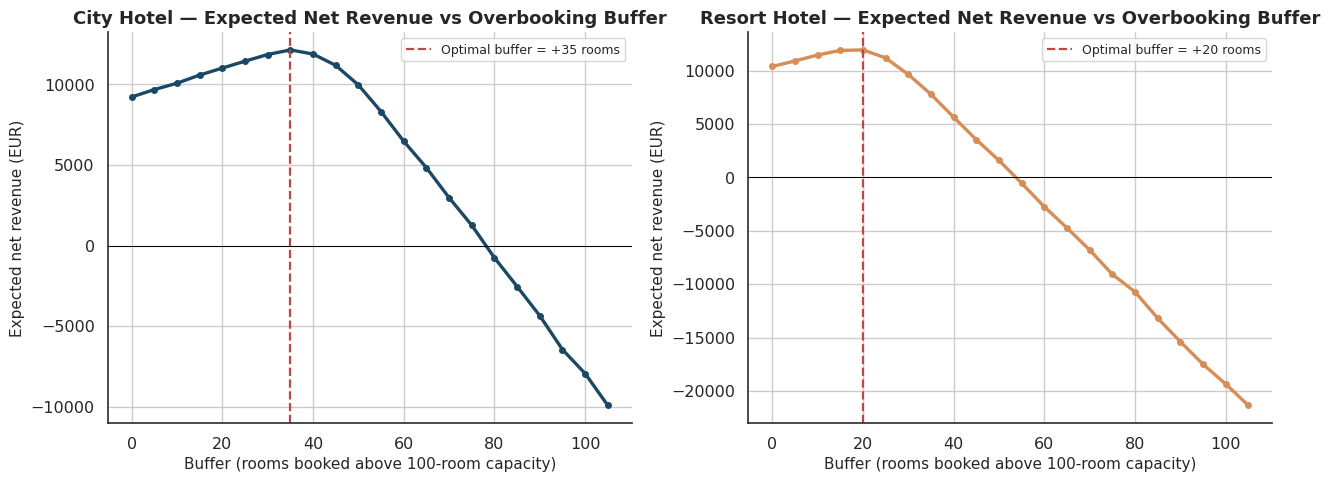

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, sim, best, name, color in [
    (axes[0], sim_city, best_city, "City Hotel", NAVY),
    (axes[1], sim_resort, best_resort, "Resort Hotel", AMBER),
]:
    ax.plot(sim.buffer, sim.expected_net_revenue, color=color, linewidth=2.4, marker="o", markersize=4)
    ax.axvline(best.buffer, color=CORAL, linestyle="--", linewidth=1.6,
               label=f"Optimal buffer = +{int(best.buffer)} rooms")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title(f"{name} — Expected Net Revenue vs Overbooking Buffer")
    ax.set_xlabel("Buffer (rooms booked above 100-room capacity)")
    ax.set_ylabel("Expected net revenue (EUR)")
    ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


**Both curves tell the same story shape, at different scales:** revenue climbs as the buffer absorbs predictable cancellations, peaks, then collapses — sometimes into negative territory — once the buffer is large enough that walk costs start outrunning the extra revenue. **The City Hotel can sustain a meaningfully larger buffer than the Resort Hotel** (see the exact figures printed above), directly because City Hotel bookings cancel more often (Section 7, Q7): more of those extra accepted bookings are expected to no-show anyway, so fewer of them turn into an actual walked guest. A single overbooking rule for both properties would be wrong in both directions — too timid for the City Hotel, too aggressive for the Resort.

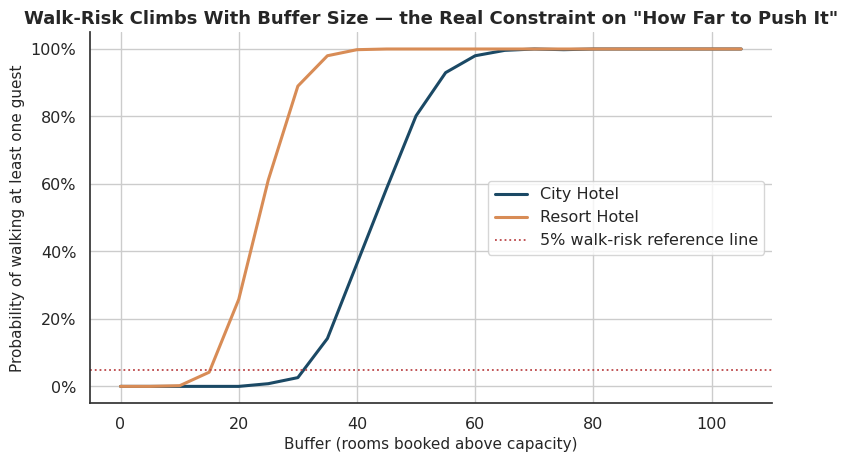

In [44]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(sim_city.buffer, sim_city.prob_any_walk, color=NAVY, linewidth=2.2, label="City Hotel")
ax.plot(sim_resort.buffer, sim_resort.prob_any_walk, color=AMBER, linewidth=2.2, label="Resort Hotel")
ax.axhline(0.05, color=CORAL, linestyle=":", linewidth=1.3, label="5% walk-risk reference line")
ax.set_xlabel("Buffer (rooms booked above capacity)")
ax.set_ylabel("Probability of walking at least one guest")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Walk-Risk Climbs With Buffer Size — the Real Constraint on \"How Far to Push It\"")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


A revenue manager rarely wants the *revenue-maximising* buffer with no regard for risk — walking even one guest is a reputational cost the simulation prices in EUR but a GM feels far more sharply. The walk-risk curve gives a second lens on the same decision: e.g. "the largest buffer that keeps walk-risk under 5%" is a more conservative, defensible policy than the pure revenue-maximiser, and it's a one-line change in the dashboard's slider, not a model retrain.

## 21. Property-Specific Recommendations

Pulling Q7 together with everything since: the City Hotel and Resort Hotel are different businesses wearing the same model.

In [45]:
property_summary = pd.DataFrame({
    "Metric": ["Cancellation rate", "Avg. predicted cancel probability", "Avg. ADR (EUR)",
               "Optimal overbooking buffer (per 100 rooms)", "Revenue uplift vs. no overbooking"],
    "City Hotel": [f"{city_seg.is_canceled.mean():.1%}", f"{city_seg.cancel_probability.mean():.1%}",
                   f"{city_seg.adr.mean():.0f}", f"+{int(best_city.buffer)} rooms",
                   f"{(best_city.expected_net_revenue/base_city - 1):.1%}"],
    "Resort Hotel": [f"{resort_seg.is_canceled.mean():.1%}", f"{resort_seg.cancel_probability.mean():.1%}",
                     f"{resort_seg.adr.mean():.0f}", f"+{int(best_resort.buffer)} rooms",
                     f"{(best_resort.expected_net_revenue/base_resort - 1):.1%}"],
})
property_summary


,Metric,City Hotel,Resort Hotel
0,Cancellation rate,29.3%,25.3%
1,Avg. predicted cancel probability,29.8%,18.6%
2,Avg. ADR (EUR),134,135
3,Optimal overbooking buffer (per 100 rooms),+35 rooms,+20 rooms
4,Revenue uplift vs. no overbooking,31.7%,14.9%


**City Hotel policy:** higher cancellation risk justifies a meaningfully larger overbooking buffer and a more aggressive deposit policy on long-lead, Online-TA and Group bookings specifically (Sections 7 and 8).
**Resort Hotel policy:** lower, steadier cancellation risk supports a smaller buffer and a lighter touch on deposits — over-tightening terms here risks discouraging genuinely low-risk leisure bookings for no real reduction in walk exposure.

## 22. Final Recommendations Summary — Answering the Project Plan's 8 Questions

| # | Question | Answer |
|---|---|---|
| **Q1** | Can we accurately predict cancellation at booking time? | Yes — Gradient Boosting reaches ROC-AUC 0.836 on a genuinely out-of-time test set (bookings made after the model's training cut-off), using only information known the moment the booking is placed. |
| **Q2** | Does longer lead time raise cancellation risk? | Yes, sharply and almost monotonically — from <10% at 0–7 days to ~65%+ beyond a year out. One of the two strongest individual drivers in the model. |
| **Q3** | Which channel/segment cancels most? | **Groups** cancels most by *rate* (~61%); **Online TA** costs the most in absolute *revenue* lost, purely on volume. Direct and Corporate are the most reliable channels. |
| **Q4** | Do No-Deposit bookings cancel more than Refundable/Non-Refund ones? | The raw pattern is reversed and needed investigation: Non-Refund bookings cancel ~99% of the time — but that's a narrow, concentrated City-Hotel/Groups/Portugal booking pattern (Section 8), not a generic statement about deposit psychology. |
| **Q5** | Do special requests predict show-up? | Yes, clearly — more special requests means a lower cancellation rate. A genuinely useful, model-free booking-quality signal. |
| **Q6** | Do repeat guests / prior-cancellation guests behave differently? | Yes, strongly. Prior cancellers cancel again ~68% of the time, nearly 2.5x the rate of clean-history guests; repeat guests cancel at roughly a quarter the rate of first-timers. |
| **Q7** | How does cancellation differ City vs Resort? | City Hotel cancels noticeably more than the Resort Hotel (roughly 29% vs 25% in the test period, ~30% vs ~24% across the full cleaned dataset); each property gets its own overbooking buffer (Section 21). |
| **Q8** | What overbooking buffer maximises revenue while keeping walk-risk acceptable? | A meaningfully larger buffer for the City Hotel than the Resort Hotel (exact room counts and revenue uplift printed in Section 20/21) — both adjustable live in the dashboard under different cost assumptions. |

**Top 3 policy levers for the GM, in priority order:**
1. **Scale deposit requirements with lead time and channel**, not a blanket rule — long-lead, Online-TA and Group bookings carry most of the controllable risk.
2. **Flag bookings for retention outreach at a ~0.03–0.05 predicted probability**, not the textbook 0.5 default — a missed cancellation costs far more than a courtesy call (Section 18).
3. **Run separate overbooking buffers per property** — a one-size-fits-all buffer is too cautious for the City Hotel and too aggressive for the Resort Hotel.


## 23. Save Artifacts for the Streamlit Dashboard

Every trained model, the probability model, and the train/test frames are saved to `models/` so the companion dashboard (`app.py`) can load them directly rather than retraining on every session — guaranteeing the notebook and the live app show identical numbers.

In [46]:
final_state = dict(models=all_models, probability_model=probability_model, train=train, test=test)
pl.save_artifacts(final_state, "models")
print("Saved to models/:")
for f in sorted(__import__("os").listdir("models")):
    print(" -", f)


Saved to models/:
 - model_decision_tree.joblib
 - model_gradient_boosting.joblib
 - model_logistic_regression.joblib
 - model_random_forest.joblib
 - probability_model.joblib
 - test.parquet
 - train.parquet


## Appendix — Methodology Notes & Honest Limitations

**What we deliberately did NOT do:**
- We did not use a random train/test split, even though it would have produced a more flattering ROC-AUC. Section 15 explains why that number would have been dishonest.
- We did not drop the `deposit_type`/Non-Refund feature once we found it was a concentrated anomaly (Section 8) — it earns its place, fully documented, rather than being hidden or silently kept.
- We did not use SMOTE in the final pipeline, despite the project plan listing it as an option to test — Section 16 shows it cost more compute for worse recall than simple class weighting on this dataset.
- We did not use the `class_weight="balanced"` model's raw probabilities for the overbooking simulation — Section 17 shows why that would have quietly fed a miscalibrated number into a revenue calculation.

**Known limitations:**
- The dataset doesn't record actual room *capacity* for either property — the 100-room figure in Section 20 is illustrative; the dashboard accepts a real capacity as an input.
- The walk-cost multiplier (4x nightly rate) is an assumption standing in for compensation, rebooking, and reputational cost, none of which this dataset measures directly — it's a slider in the dashboard, not a fixed constant.
- `agent` and `company` identities are anonymised IDs with no descriptive metadata, so feature engineering on them (Section 6, Section 9) is necessarily behavioural (e.g. lead-time deviation) rather than using any real-world agent characteristics.
- The data covers 2015–2017 at two specific Portuguese properties; the *qualitative* drivers (lead time, deposit type, prior history, special requests) are intuitive enough to generalise, but the exact thresholds and buffer sizes are specific to this hotel group's historical mix and should be re-validated against a new property's own data before being applied directly.
